In [1]:
#installing necessary libraries
!pip install -q transformers accelerate bitsandbytes torch datasets gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 12.2 MB/s eta 0:00:00


In [3]:
# Hugging Face Login

import os
from huggingface_hub import login, notebook_login

print("Attempting Hugging Face login...")

notebook_login()
print("Login successful (or token already present)!")

Attempting Hugging Face login...
Login successful (or token already present)!


In [4]:
#Import necessary libraries
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from datasets import load_dataset  # Import the dataset loading function
import gradio as gr
from IPython.display import display, Markdown
import random  # To pick random news items

# Check for GPU availability
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    torch.set_default_device("cuda")
    print("PyTorch default device set to CUDA (GPU).")
else:
    print("WARNING: No GPU detected. Performance will be very slow.")
    print("Go to Runtime > Change runtime type and select GPU.")

GPU detected: Tesla T4
PyTorch default device set to CUDA (GPU).


In [6]:
# Helper function for markdown display
def print_markdown(text):
    """Displays text as Markdown."""
    display(Markdown(text))

In [7]:
dataset_id = "fdaudens/ai-jobs-news-articles"

print(f"Loading dataset: {dataset_id}...")

# Load the dataset (will download if not cached)
# We might only need the 'train' split, specify split = 'train' if needed
# The datatype of news_dataset is datasets.Dataset (from the datasets library by Hugging Face).
news_dataset = load_dataset(dataset_id, split = "train")
print("Dataset loaded successfully!")

Loading dataset: fdaudens/ai-jobs-news-articles...


README.md:   0%|          | 0.00/766 [00:00<?, ?B/s]

(…)s%20-%20ai_jobs_news_20250617_140957.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset loaded successfully!


In [8]:
# Let's Inspect the dataset
news_dataset

Dataset({
    features: ['title', 'link', 'snippet', 'text', 'date', 'source', 'imageUrl', 'position', 'search_keyword', 'fetch_timestamp', 'date_parsed'],
    num_rows: 1000
})

In [9]:
# Let's display the features (columns and their types)
print("\n Dataset Features")
print(news_dataset.features)


 Dataset Features
{'title': Value('string'), 'link': Value('string'), 'snippet': Value('string'), 'text': Value('string'), 'date': Value('string'), 'source': Value('string'), 'imageUrl': Value('string'), 'position': Value('int64'), 'search_keyword': Value('string'), 'fetch_timestamp': Value('string'), 'date_parsed': Value('float64')}


In [10]:
# Let's view the datasets as a Pandas DataFrame
news_dataset.to_pandas()

,title,link,snippet,text,date,source,imageUrl,position,search_keyword,fetch_timestamp,date_parsed
0,AI is stealing entry-level jobs from universit...,https://thelogic.co/news/ai-graduate-jobs-univ...,Entry-level jobs are increasingly being done b...,AI is stealing entry-level jobs from universit...,1 day ago,The Logic,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",1,AI impact jobs,2025-06-17 14:02:24,NaN
1,AI and future of jobs: Here’s what top tech CE...,https://indianexpress.com/article/technology/a...,"In recent months, more and more tech CEOs have...",# AI and future of jobs: Here’s what top tech ...,6 hours ago,The Indian Express,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",2,AI impact jobs,2025-06-17 14:02:24,NaN
2,I asked 4 founders if they are worried about A...,https://www.yahoo.com/news/asked-4-founders-wo...,"Founders are embracing AI at their startups, b...",I asked 4 founders if they are worried about A...,3 hours ago,Yahoo,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",3,AI impact jobs,2025-06-17 14:02:24,NaN
3,The scariest thing about AI might be the way y...,https://www.businessinsider.com/how-ceos-talk-...,Some CEOs have said they expect AI to displace...,The scariest thing about AI might be the way y...,3 days ago,Business Insider,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",4,AI impact jobs,2025-06-17 14:02:24,NaN
4,LinkedIn cofounder Reid Hoffman says AI job fe...,https://www.indiatoday.in/technology/news/stor...,While acknowledging that the technology's impa...,"AI job fear is legitimate, but Gen Z grads hav...",2 days ago,India Today,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",5,AI impact jobs,2025-06-17 14:02:24,NaN
...,...,...,...,...,...,...,...,...,...,...,...
995,How Apexon’s AI redefines workforce resilience,https://www.hrkatha.com/features/how-apexons-a...,Apexon's proprietary AI goes beyond merely ide...,How Apexon’s AI redefines workforce resilience...,6 months ago,HR Katha,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",44,machine learning workforce,2025-06-17 14:03:31,NaN
996,How AI will affect future workforce: Key consi...,https://safety4sea.com/cm-how-ai-will-affect-f...,"In today's rapid world, the convergence of art...","n today’s rapid world, the convergence of arti...",10 months ago,safety4sea,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",45,machine learning workforce,2025-06-17 14:03:31,NaN
997,The future of work: Integrating AI into workfo...,https://www.expresscomputer.in/guest-blogs/the...,"By Anurag Gupta, Co founder, STEMROBO Technolo...",The future of work: Integrating AI into workfo...,8 months ago,Express Computer,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",47,machine learning workforce,2025-06-17 14:03:31,NaN
998,AI development works better for everyone when ...,https://theconversation.com/ai-development-wor...,"Studies have shown, for example, that remote w...",AI development works better for everyone when ...,7 months ago,The Conversation,"data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQA...",48,machine learning workforce,2025-06-17 14:03:31,NaN


In [11]:
# Let's prepare the data for the LLM
# We'll combine title and description for the input text
def combine_news_text(example):

    # Handle potential None values gracefully
    title = example.get("title", "") or ""
    text = example.get("text", "") or ""

    # Add a separator for clarity
    return {"full_text": f"Title: {title}\nText: {text}"}

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


--- Sample Data with 'full_text' ---
{'title': 'AI is stealing entry-level jobs from university graduates', 'link': 'https://thelogic.co/news/ai-graduate-jobs-university-of-waterloo/', 'snippet': 'Entry-level jobs are increasingly being done by AI, making it harder for graduates to get into the job market and gain crucial experience.', 'text': 'AI is stealing entry-level jobs from university graduates\nBy Catherine McIntyre\nJun 16, 2025\n\nTORONTO — University graduates have new competition in the job market: AI. Recruiters, business consultants and university representatives say tools like ChatGPT are increasingly occupying the first rung of the employment ladder, making it harder for graduates to get into the job market. As a result, many people graduating this summer are struggling to find jobs as AIs do the work typically given to interns and co-op students.\n\nChris Brulak, founder of Toronto-based tech recruitment firm DevTalent, said some of his clients have pared back the num
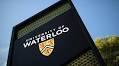

In [12]:
# Let's apply the function to combine the 'title' and 'description' into 'full_text'
# This uses map, which is efficient for datasets

news_dataset = news_dataset.map(combine_news_text)

print("\n--- Sample Data with 'full_text' ---")
print(news_dataset[0])

In [13]:
# Let's display the full_text of the first sample
print(news_dataset[0]["full_text"])

Title: AI is stealing entry-level jobs from university graduates
Text: AI is stealing entry-level jobs from university graduates
By Catherine McIntyre
Jun 16, 2025

TORONTO — University graduates have new competition in the job market: AI. Recruiters, business consultants and university representatives say tools like ChatGPT are increasingly occupying the first rung of the employment ladder, making it harder for graduates to get into the job market. As a result, many people graduating this summer are struggling to find jobs as AIs do the work typically given to interns and co-op students.

Chris Brulak, founder of Toronto-based tech recruitment firm DevTalent, said some of his clients have pared back the number of software developers on staff as they use AI tools to replace their work. “The mindset is, ‘We’ll hire one developer that’s comfortable with an AI tool, and they’ll be five to 10 times more productive,’” said Brulak. “That eats away at the entry-level software developer role.”

In [14]:
# Load Deepseek Reasoning Model

model_id = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
print(f"Loading model: {model_id}")
print("This may take a few minutes...")

# Define the BitsAndBytesConfig for 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=False,
)

model = AutoModelForCausalLM.from_pretrained(model_id,
                                             torch_dtype = "auto",
                                             quantization_config = bnb_config,
                                             device_map = "auto",
                                             trust_remote_code = True)

model.eval()
print("Model loaded successfully in 4-bit!")

Loading model: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
This may take a few minutes...


config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded successfully in 4-bit!


In [15]:
# Load the Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code = True)
print("Tokenizer loaded successfully.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully.


In [16]:
# Text Generation Pipeline
llm_pipeline = pipeline("text-generation", model = model, tokenizer = tokenizer, dtype = "auto", device_map = "auto")
print("Text generation pipeline created successfully.")

Text generation pipeline created successfully.


In [17]:
# Formatted prompt:

test_question = "Explain what electric cars are in simple terms. Keep the thinking short."
test_prompt = f"<|im_start|>user\n{test_question}<|im_end|>\n<|im_start|>assistant\n<think>\n"
print(f"Test prompt:\n{test_prompt}")

Test prompt:
<|im_start|>user
Explain what electric cars are in simple terms. Keep the thinking short.<|im_end|>
<|im_start|>assistant
<think>



In [18]:
# Testing the model

print("Testing model with a simple instruction")

outputs = llm_pipeline(test_prompt,
                       max_new_tokens = 4000,
                       do_sample = True,
                       temperature = 0.7,
                       top_p = 0.9)

outputs

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'top_p', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing model with a simple instruction


[{'generated_text': '<|im_start|>user\nExplain what electric cars are in simple terms. Keep the thinking short.<|im_end|>\n<|im_start|>assistant\n<think>\nAlright, I need to explain what electric cars are in simple terms. The user asked for a short and simple explanation, so I should keep it concise without getting too technical. Maybe I can start by mentioning cars that run on electricity instead of internal combustion engines. Then, explain what electric cars specifically are, probably focusing on their features and benefits like reducing reliance on fossil fuels and promoting sustainability. Keep it straightforward, maybe in bullet points or short sentences. I should avoid jargon and make it easy to understand.\n</think>\n\nElectric cars are cars that run on electricity instead of internal combustion engines. They are designed to be more efficient and environmentally friendly compared to traditional cars.'}]

In [19]:
# Function to extract and format the reason and output
def format_model_output(output):

    # Extract the content within <think> tags as Reason
    reason_start = output.find("<think>") + len("<think>")
    reason_end = output.find("</think>")
    reason = output[reason_start:reason_end].strip()

    # Extract the content after </think> as Output
    output_start = reason_end + len("</think>")
    model_output_content = output[output_start:].strip()

    # Format the result
    reason = f"**Reason**:\n{reason}\n"
    output = f"**Output**:\n{model_output_content}"
    return reason, output

In [20]:
# Extract and print the generated text (only the response part)
full_output = outputs[0]["generated_text"]
reason, output = format_model_output(full_output)
print_markdown(reason + output)

**Reason**:
Alright, I need to explain what electric cars are in simple terms. The user asked for a short and simple explanation, so I should keep it concise without getting too technical. Maybe I can start by mentioning cars that run on electricity instead of internal combustion engines. Then, explain what electric cars specifically are, probably focusing on their features and benefits like reducing reliance on fossil fuels and promoting sustainability. Keep it straightforward, maybe in bullet points or short sentences. I should avoid jargon and make it easy to understand.
**Output**:
Electric cars are cars that run on electricity instead of internal combustion engines. They are designed to be more efficient and environmentally friendly compared to traditional cars.

In [21]:
import re  # Import regular expressions for parsing

def analyze_news_sentiment(news_text, llm_pipeline):
    """
    Analyzes news sentiment using the LLM, providing reasoning and classification.

    Args:
        news_text (str): The combined title and description of the news.
        llm_pipeline (transformers.pipeline): The initialized text-generation pipeline.

    Returns:
        str: A string containing the reasoning and classification.
    """

    # Define the Prompt Template with specific instructions for the model
    test_question = f"""You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    {news_text}"""

    # Format the prompt according to DeepSeek's expected input format with thinking tags
    test_prompt = f"<|im_start|>user\n{test_question}<|im_end|>\n<|im_start|>assistant\n<think>\n"

    # Print the prompt for debugging purposes to verify what's being sent to the model
    print(f"Test prompt:\n{test_prompt}")

    # Run the model inference with specific generation parameters
    outputs = llm_pipeline(
        test_prompt,
        max_new_tokens = 4000,
        do_sample = True,
        temperature = 0.7,
        top_p = 0.9)

    # Extract the full generated text and parse it to separate reasoning from classification
    # The format_model_output function likely separates the thinking process from the final answer
    full_output = outputs[0]["generated_text"]
    reason, output = format_model_output(full_output)

    # Return both the reasoning process and the final sentiment classification
    return reason, output

In [22]:

# Print a separator line for clarity in the output
print("\n" + "=" * 30 + " TESTING ANALYSIS " + "=" * 30)


# Select a few random indices from the news dataset to test the analysis function
random_indices = random.sample(range(len(news_dataset)), 3)

# Iterate over each randomly selected index
for index in random_indices:
    # Retrieve the full text of the news item at the current index
    sample_news = news_dataset[index]["full_text"]

    # Analyze the sentiment of the sample news using the sentiment analysis function
    reason, output = analyze_news_sentiment(sample_news, llm_pipeline)

    # Print the analysis result header for the current index
    print(f"\n--- Analysis Result for Index {index} ---")

    # Display the reasoning and output in a formatted markdown style
    print_markdown(f"{reason}\n\n{output}")

    # Print a separator line for better readability between results
    print("-" * 60)


Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



============================== TESTING ANALYSIS ==============================
Test prompt:
<|im_start|>user
You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    Title: Automation Could Eliminate 73 Million U.S. Jobs By 2030
Text:  
Dec 1, 2017
The rapid evolution of AI and robots could eliminate 73 million American jobs by 2030, according to a new report from the McKinsey Global Institute. The research notes that those losses could be offset by an increase in productivity, economic growth and other factors. However, maintaining full employment is likely to be highly challenging as the economy and l

**Reason**:
Alright, let's tackle this step by step. First, I need to understand what the user is asking for. They provided a news text about automation and job losses in the U.S., and they want me to analyze it, outputting three specific items: a reasoning, sentiment, and tag. Each of these should be in a new line, prefixed by their labels.

So, starting with the reasoning. The news text mentions job losses due to automation, so I need to briefly explain that. It's about 73 million jobs being eliminated by 2030, so the reasoning should convey that.

Next, sentiment. The user specified to choose one: Positive, Negative, Neutral. Looking at the news text, it's clear that automation is causing job losses, which is a negative impact. So, the sentiment here should be Negative.

Lastly, the tag. It should be a concise topic tag. The news text is about job losses due to automation, so a suitable tag would be "Job Losses by Automation."

I need to make sure that each of these outputs is on a new line, prefixed by their labels as specified. Also, no additional text, greetings, or explanations should be included. Just the three items as per the user's instructions.

Let me double-check the information. The job losses are 73 million by 2030, and they are talking about automation. So, the reasoning is accurate. The sentiment is negative because it's causing loss. The tag is correct as it's about job losses by automation.

I think that's all covered. Now, I'll format the response as per the user's instructions.


**Output**:
1. REASONING: Automation is expected to eliminate 73 million U.S. jobs by 2030.
2. SENTIMENT: Negative
3. TAG: Job Losses by Automation

Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


------------------------------------------------------------
Test prompt:
<|im_start|>user
You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    Title: How to Mitigate Automation Risks and Close the Gender Gap
Text: How to Mitigate Automation Risks and Close the Gender Gap
Our expert offers advice on empowering women in the workplace in the age of AI.
Written by Julia Grace Samoylenko
Published on Dec. 02, 2024

As artificial intelligence (AI) and automation continue to reshape industries, concerns about the disproportionate vulnerability of women in the workforce are growing. This concern is particul

**Reason**:
Okay, so I'm looking at this news text about automating jobs and the risks of women being left behind. It's pretty technical, and I'm not entirely sure what to make of it. Let me try to break it down step by step.

First, the title is "How to Mitigate Automation Risks and Close the Gender Gap." That's a bit vague, but it seems like it's talking about ways to reduce the risks of automation and specifically address gender issues in the workplace. The text also mentions Julia Grace Samoylenko, an expert offering advice on empowering women in the age of AI.

The publication date is December 2, 2024. The article is written in English and seems to focus on AI and automation. It's divided into several sections, each discussing different aspects of AI's impact on the workforce.

The first section talks about AI and how it's reshaping industries. It mentions concerns about women being left behind in routine roles, which are heavy on administrative, healthcare, and customer service sectors. It also discusses how AI can create gender disparities unless organizations take proactive steps.

The second section discusses how AI can support women in the workforce. It mentions AI-driven skill inference tools and AI skills mapping. It also talks about how AI can be used to analyze employee skills and performance, and how organizations can upskil and reskill their workforce.

The third section discusses how AI can promote gender equality in the workforce. It mentions organizations adopting AI-driven workforce intelligence tools and using AI to analyze employee skills and performance. It also talks about how women can transition to roles that require uniquely human capabilities, such as creativity, problem-solving, and strategic thinking.

The fourth section talks about how organizations can ensure an equitable AI future. It mentions businesses and policymakers needing to prioritize inclusivity and support for women in the workforce. It also discusses how organizations can create pathways for women to thrive in emerging roles.

Overall, the article seems to be a discussion about the risks and opportunities of AI in the workforce, with a particular focus on how women can be leveraged to overcome these risks. It's quite comprehensive, covering both the challenges and the opportunities.

However, I'm a bit confused about the exact sentiment of the article. It seems to be neutral because it doesn't explicitly state a positive or negative opinion. It's more about discussing the potential and risks of AI in the workforce.

I also notice that the article is quite technical, discussing AI and automation in detail. It might be more suitable for people with a technical background or those interested in AI and workforce development.

In terms of the three requested items, the first would be a brief financial reasoning based on the article. The article is discussing the risks and opportunities of AI in the workforce, so the financial reasoning might be about the potential benefits or risks in terms of job displacement or gender discrimination.

The second would be the sentiment, which, as I noted earlier, is neutral because it doesn't explicitly state a positive or negative opinion.

The third would be the tag, which is a concise topic tag. Given the article is discussing AI in the workforce and the risks associated with women, the tag could be something like "AI in Workforce Development and Gender Equality."

Putting it all together, the assistant would output the three requested items as described.


**Output**:
1. **Financial Reasoning**: The article discusses the potential benefits and risks associated with AI in the workforce, including the risks of women being left behind due to automation. While the article doesn't explicitly state a positive or negative opinion, it does provide a brief financial context of the risks associated with AI automation.

2. **Sentiment**: The article is neutral because it doesn't explicitly state a positive or negative opinion. It discusses the potential benefits and risks of AI in the workforce, focusing on the challenges women face and the opportunities AI presents.

3. **Tag**: The tag could be "AI in Workforce Development and Gender Equality." This succinctly captures the topic of the article, which discusses the intersection of AI in workforce development and the gender equality challenges within that context.

Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


------------------------------------------------------------
Test prompt:
<|im_start|>user
You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    Title: You See? Generative AI is Bad At Doing My Job
Text: You See? Generative AI is Bad At Doing My Job 
Maris Kreizman on the AI Hallucinations That Made it to the Book Review Section
By Maris Kreizman
May 22, 2025

This past Tuesday I received 37 pitches for upcoming books from 37 different publicists representing 37 different authors. I am always aware of how many books keep coming out and how little space there is to cover any of them. And it’s particula

**Reason**:
Okay, so I'm looking at this news text about AI being bad at doing someone's job. The title is "You See? Generative AI is Bad At Doing My Job." The author is Maris Kreizman, and it's published on May 22, 2025. The text mentions Maris Kreizman and her pitches for upcoming books, with 37 pitches received by 37 different publicists. That's interesting because it's showing how many books are out there and how many are getting picked.

Then there's a mention of Maris Kreizman sharing a pitch with Maris Kreizman herself on the AI hallucinations that made it to the book review section. That's a bit more personal, showing that she's aware of the issues AI might cause.

The text also points out that newspapers like the Chicago Sun Times and the Philadelphia Enquirer have published summer reading lists that include many AI hallucinations. These are called The Longest Day by Rumaan Alam, which is an example of this. So, it's showing that these lists are not just for fun or exercise but are actually about the heat index, which is a real thing. The AI is hallucinating about the heat index, which is a real issue.

The text also mentions that these lists are being licensed from King Features, a content distribution studio owned by Hearst. It suggests that this might be a mild consolation that the writing isn't assigned or commissioned by the newspapers' editorial staff. It adds that someone at both papers had licensed the package from King Features, and they made a mistake. The timing of this latest LLM (large language model) error is telling, as it happened after recent layoffs at both papers.

The author also writes about how there are too many books being published while there's declining space for book coverage and arts coverage in general. They mention that most books are written with care and edited with care and published with care. Getting the word out about one of these books is difficult enough without having to compete with books that don't exist.

They also mention that getting the word out about one of these books is difficult enough without having to compete with books that don't exist. They also talk about the effort to create book lists for publications, and they mention that they've written elsewhere about the effort to create any sort of book list for which they freelance. They also talk about how there are so many factors to consider when putting together a list, and they suggest that ChatGPT can't do this, and now it's just a matter of convincing the world, including media bosses and readers alike, that there is value in what they do.

They also talk about how the King Features summer reading list, along with the rest of the package that appears to have been vomited out by some AI model and not looked over once by human eyes, is just the latest insult by corporate media to people who care about the written word. It's an insult to journalists who care about the truth, to authors who are looking to get any coverage they can, to book critics and anyone who works on putting books out into the world. More importantly, it's an insult to readers.

Finally, the author mentions that the King Features summer reading list, along with the rest of the package that appears to have been vomited out by some AI model and not looked over once by human eyes, is just the latest insult by corporate media to people who care about the written word. It's an insult to journalists who care about the truth, to authors who are looking to get any coverage they can, to book critics and anyone who works on putting books out into the world. More importantly, it's an insult to readers.

So, to summarize the key points in the news text:

1. AI is being used to hallucinate the heat index, which is a real issue.
2. Newspapers are publishing summer reading lists that include many AI hallucinations.
3. The lists are being licensed from King Features, a content distribution studio owned by Hearst.
4. There are declining space for book coverage and arts coverage in general.
5. Most books are written with care and edited with care and published with care.
6. Getting the word out about one of these books is difficult enough without having to compete with books that don't exist.
7. The effort to create book lists for publications is significant.
8. The King Features summer reading list, along with the rest of the package that appears to have been vomited out by some AI model and not looked over once by human eyes, is just the latest insult by corporate media to people who care about the written word. It's an insult to journalists who care about the truth, to authors who are looking to get any coverage they can, to book critics and anyone who works on putting books out into the world. More importantly, it's an insult to readers.

So, the user wants to analyze this news text and output only three specific items: the reasoning, sentiment, and tag.


**Output**:
1. **Reasoning**: The AI is hallucinating the heat index, which is a real issue affecting real people.

2. **Sentiment**: Negative.

3. **Tag**: A concise topic tag (1-3 words).

------------------------------------------------------------


In [23]:
import gradio as gr  # Importing the Gradio library for creating the web interface
import random  # Importing the random library to generate random numbers
import re  # Importing the regular expressions library (not used in this snippet)
from transformers import pipeline  # Importing the pipeline function from transformers for model loading

# --- Gradio Helper Functions ---
def get_random_news():
    """Fetches and returns the full_text of a random news item."""
    if not news_dataset:  # Check if the news dataset is empty
        return "Error: No news items available."  # Return an error message if no news items are found
    random_index = random.randint(0, len(news_dataset) - 1)  # Generate a random index to select a news item
    news_text = news_dataset[random_index]['full_text']  # Retrieve the full text of the news item at the random index
    print(f"Fetched news item at index {random_index}")  # Print the index of the fetched news item
    return news_text  # Return the fetched news text

def perform_analysis(news_text):
    """Triggers analysis on the provided news text."""
    if not news_text or news_text.startswith("Error"):  # Check if the news text is empty or an error message
        return "Error: No news text to analyze."  # Return an error message if no valid news text is provided
    print(f"Analyzing news: {news_text[:50]}...")  # Print the first 50 characters of the news text being analyzed
    reason, output = analyze_news_sentiment(news_text, llm_pipeline)  # Analyze the sentiment of the news text
    return reason, output  # Return the reasoning and output from the analysis

# --- Build Gradio Interface ---
with gr.Blocks(theme=gr.themes.Glass()) as demo:  # Create a Gradio Blocks interface with a glass theme
    gr.Markdown("""
    # DeepSeek Financial News Analyzer
    Fetches a random news item from the dataset.
    Click 'Analyze News' to get sentiment classification and the model's reasoning.

    """)

    with gr.Row():  # Create a row for buttons
        btn_fetch = gr.Button("🔄 Fetch Random News Item")  # Button to fetch a random news item
        btn_analyze = gr.Button("💡 Analyze News", variant="primary")  # Button to analyze the news

    news_display = gr.Textbox(  # Textbox to display the news item
        label="📰 News Text (Title & Description)",  # Label for the textbox
        lines=8,  # Number of lines in the textbox
        interactive=False,  # Make the textbox non-interactive
        placeholder="Click 'Fetch Random News Item' to display news."  # Placeholder text
    )
    # Creates a collapsible panel
    with gr.Accordion("🤖 Model Reason", open=True):  # Accordion for model reasoning
        analysis_display = gr.Markdown()  # Markdown display for the reasoning

    with gr.Accordion("🤖 Model Output", open=True):  # Accordion for model output
        analysis_output = gr.Markdown()  # Markdown display for the output

    # --- Event Handlers ---
    btn_fetch.click(  # Set up click event for the fetch button
        fn=get_random_news,  # Function to call when the button is clicked
        inputs=[],  # No inputs needed
        outputs=[news_display]  # Output to the news display textbox
    )

    btn_analyze.click(  # Set up click event for the analyze button
        fn=perform_analysis,  # Function to call when the button is clicked
        inputs=[news_display],  # Input from the news display textbox
        outputs=[analysis_display, analysis_output]  # Outputs to the reasoning and output displays
    )

    # Load initial news item when the app starts
    demo.load(  # Load function to run when the app starts
        fn=get_random_news,  # Function to call to get a random news item
        inputs=None,  # No inputs needed
        outputs=[news_display]  # Output to the news display textbox
    )

# --- Launch the Gradio App ---
print("Launching Gradio demo...")  # Print message indicating the app is launching
demo.launch(debug=True)  # Launch the Gradio app in debug mode

/tmp/ipython-input-1399811874.py:25: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Glass()) as demo:  # Create a Gradio Blocks interface with a glass theme


Launching Gradio demo...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7a5a8b2c3f7bf4fa09.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Fetched news item at index 891


Both `max_new_tokens` (=4000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Analyzing news: Title: How Will ChatGPT Affect Jobs?
Text: Gary Fo...
Test prompt:
<|im_start|>user
You are a concise Financial News Analyst.
    Analyze the provided news text. Output ONLY the three requested items below, each on a new line, prefixed with the specified label.

    1.  REASONING: Brief financial reasoning (1-2 points max) for the sentiment.
    2.  SENTIMENT: Choose ONE: Positive, Negative, Neutral.
    3.  TAG: A concise topic tag (1-3 words).

    Do NOT add any other text, greetings, or explanations.

    News Text:
    Title: How Will ChatGPT Affect Jobs?
Text: Gary Fowler is a serial AI entrepreneur with numerous startups and an IPO. 
He is CEO and cofounder of GSDVS.com and Yva.ai. gettySince its quick and storm-like takeover of users’ day-to-day, OpenAI’s 
ChatGPT has passed medical school exams, software engineer coding 
interviews, the bar exam and much more.More than anything, ChatGPT might just be the very first example of 
commercial adoption of an AI tool—